In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from utils import MEASURED_BANDWIDTH, MEASURED_BANDWIDTH_STR

In [16]:
dtype_to_bytes = {
    "float64": 8,
    "float32": 4,
    "float16": 2,
    "bfloat16": 2,
}

In [17]:
df = pd.read_csv("../results/benchmark_batched_gemv.csv")
df["times (ms)"] = df["times (ms)"].apply(ast.literal_eval)
df["time (ms)"] = df["times (ms)"].apply(min)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms)
0,33554432,2,float32,float32,irrespective,"[0.6574832153320312, 0.6529942321777343, 0.652...",3.591310e-04,0.652654
1,33554432,2,float32,float32,synchronized,"[0.6897212982177734, 0.6890662384033203, 0.688...",3.591310e-04,0.688909
2,33554432,2,float32,float32,torch,"[32.88481140136719, 32.901919555664065, 32.944...",4.251023e-04,32.884811
3,33554432,2,float16,float32,irrespective,"[0.5210451126098633, 0.5100006484985351, 0.510...",3.591594e-04,0.509954
4,33554432,2,float16,float32,synchronized,"[0.6198169708251953, 0.6186412811279297, 0.618...",3.591594e-04,0.618585
...,...,...,...,...,...,...,...,...
3103,6045,149,float16,float64,synchronized,"[0.19181087493896484, 0.19353216171264648, 0.1...",5.159404e-12,0.191811
3104,6045,149,float16,float64,torch,"[0.22778816223144532, 0.22894304275512695, 0.2...",3.399413e+00,0.227788
3105,6045,149,bfloat16,float64,irrespective,"[0.2650172805786133, 0.26001888275146484, 0.26...",5.156978e-12,0.259953
3106,6045,149,bfloat16,float64,synchronized,"[0.19141759872436523, 0.1917919921875, 0.19117...",5.156978e-12,0.191177


In [18]:
def throughput(n, k, time_ms, mat_dtype, vec_dtype):
    mat_el_bytes = dtype_to_bytes[mat_dtype]
    vec_el_bytes = dtype_to_bytes[vec_dtype]
    total_bytes = n * k * k * mat_el_bytes + n * k * vec_el_bytes + n * k * vec_el_bytes
    return total_bytes / (time_ms / 1000) / 1e9

In [19]:
def flops(n, k, time_ms):
    total_flops = 2 * n * k * k
    return total_flops / (time_ms / 1000) / 1e9

In [20]:
df["throughput"] = df.apply(
    lambda row: throughput(
        n=row["n"],
        k=row["k"],
        time_ms=row["time (ms)"],
        mat_dtype=row["A_dtype"],
        vec_dtype=row["b_dtype"],
    ),
    axis=1,
)
df["GFlops"] = df.apply(
    lambda row: flops(n=row["n"], k=row["k"], time_ms=row["time (ms)"]),
    axis=1,
)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms),throughput,GFlops
0,33554432,2,float32,float32,irrespective,"[0.6574832153320312, 0.6529942321777343, 0.652...",3.591310e-04,0.652654,1645.191993,411.297998
1,33554432,2,float32,float32,synchronized,"[0.6897212982177734, 0.6890662384033203, 0.688...",3.591310e-04,0.688909,1558.610957,389.652739
2,33554432,2,float32,float32,torch,"[32.88481140136719, 32.901919555664065, 32.944...",4.251023e-04,32.884811,32.651604,8.162901
3,33554432,2,float16,float32,irrespective,"[0.5210451126098633, 0.5100006484985351, 0.510...",3.591594e-04,0.509954,1579.173837,526.391279
4,33554432,2,float16,float32,synchronized,"[0.6198169708251953, 0.6186412811279297, 0.618...",3.591594e-04,0.618585,1301.853174,433.951058
...,...,...,...,...,...,...,...,...,...,...
3103,6045,149,float16,float64,synchronized,"[0.19181087493896484, 0.19353216171264648, 0.1...",5.159404e-12,0.191811,1474.480371,1399.347613
3104,6045,149,float16,float64,torch,"[0.22778816223144532, 0.22894304275512695, 0.2...",3.399413e+00,0.227788,1241.598190,1178.332040
3105,6045,149,bfloat16,float64,irrespective,"[0.2650172805786133, 0.26001888275146484, 0.26...",5.156978e-12,0.259953,1087.971319,1032.533290
3106,6045,149,bfloat16,float64,synchronized,"[0.19141759872436523, 0.1917919921875, 0.19117...",5.156978e-12,0.191177,1479.369474,1403.987590


In [21]:
def plot_throughput(ax, mat_dtype: str, vec_dtype: str, labels: bool = False):
    max_tput = df[
        (df.A_dtype == mat_dtype) & (df.b_dtype == vec_dtype)  # & (df.k <= 128)
    ].pivot_table(values="throughput", columns="algorithm", index="k", aggfunc="max")

    title = f"{mat_dtype} $\\times$ {vec_dtype}"
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("matrix size k")
    ax.set_ylabel("throughput (GB/s)")

    ax.set_xlim(left=0, right=151)
    ax.set_ylim(bottom=0, top=1870)
    ax.set_yticks([0, 500, 1000, 1500, MEASURED_BANDWIDTH])

    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

    algorithms = df["algorithm"].unique()
    marker = {"irrespective": "s", "synchronized": "^", "torch": "o"}
    color = {
        "irrespective": "tab:blue",
        "synchronized": "tab:green",
        "torch": "tab:orange",
    }
    name_map = {
        "irrespective": "RPT-I",
        "synchronized": "RPT-S",
        "torch": "PyTorch",
    }

    for alg in algorithms:
        ax.scatter(
            x=max_tput.index,
            y=max_tput[alg],
            marker=marker[alg],
            label=name_map[alg] if labels else None,
            s=13,
            zorder=3,
            facecolors="none",
            edgecolors=color[alg],
        )

    ax.axhline(
        y=MEASURED_BANDWIDTH,
        color="red",
        linestyle="--",
        label=f"achievable A100 bandwidth" if labels else None,
    )

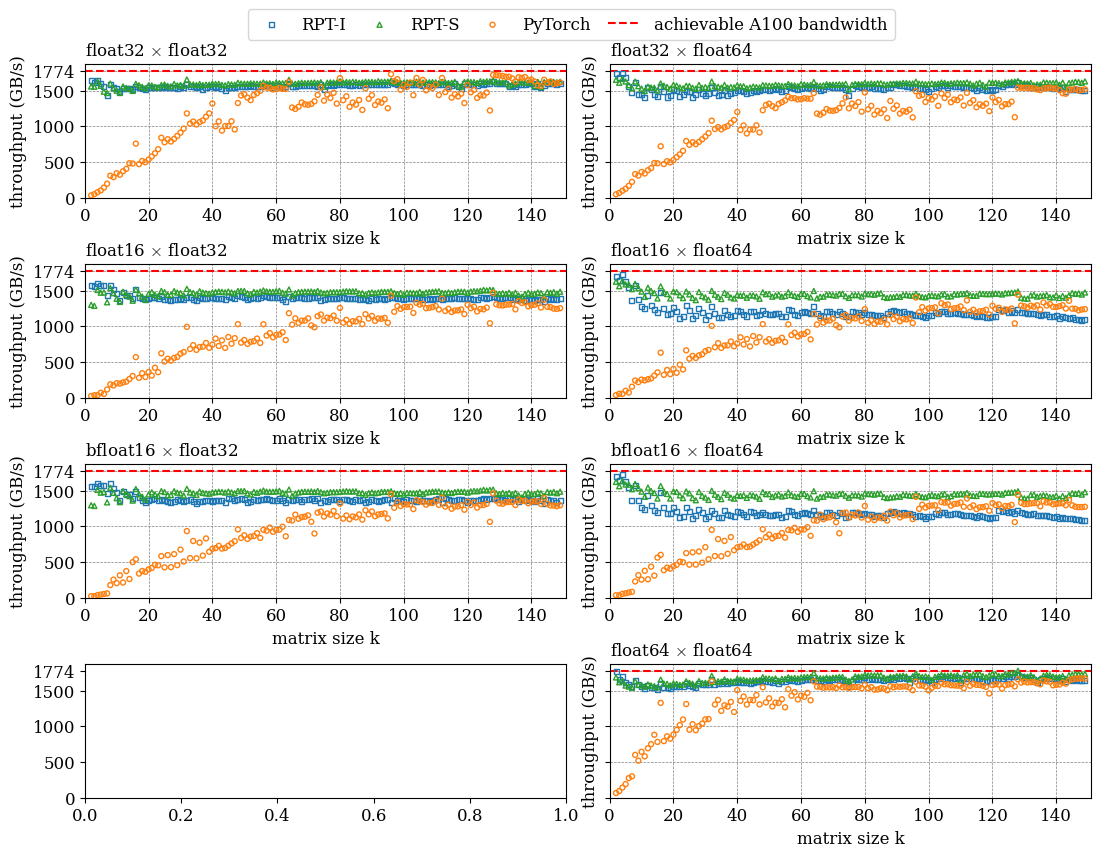

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharey=True)
fig.tight_layout(pad=1.0, h_pad=2.0)
for i, mat_dtype in enumerate(df.A_dtype.unique()):
    for j, vec_dtype in enumerate(df.b_dtype.unique()):
        if mat_dtype == "float64" and vec_dtype == "float32":
            continue
        plot_throughput(axes[i, j], mat_dtype, vec_dtype, labels=(i == 0 and j == 0))

fig.legend(ncols=5, loc="upper center", bbox_to_anchor=(0.5, 1.05), columnspacing=1)
# fig.savefig("../docs/thesis-media/matrix_vec_tput.svg", bbox_inches="tight")

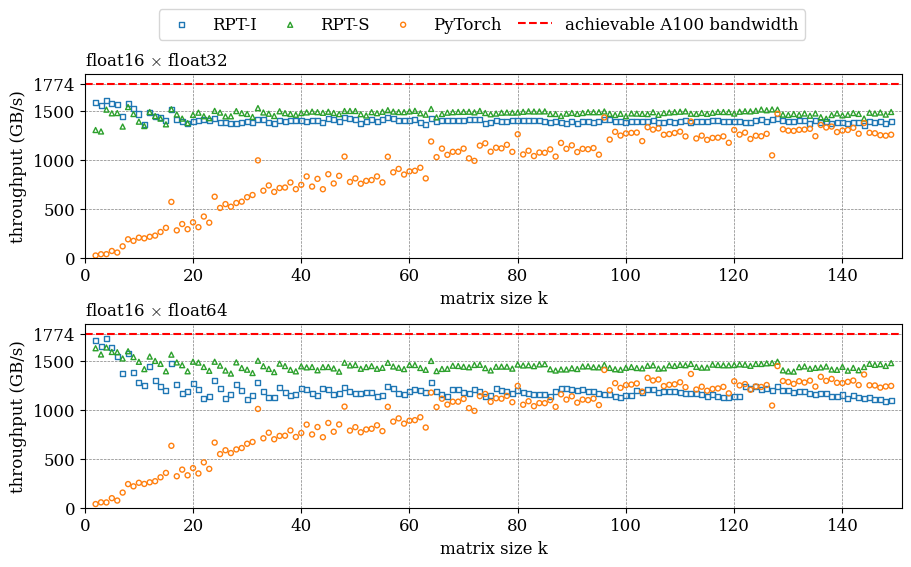

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5))
fig.tight_layout(pad=1.0, h_pad=2.0)
plot_throughput(axes[0], "float16", "float32", labels=True)
plot_throughput(axes[1], "float16", "float64", labels=False)

fig.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, 1.1), columnspacing=1)
fig.savefig("../docs/images/matrix_vec_tput.svg", bbox_inches="tight")

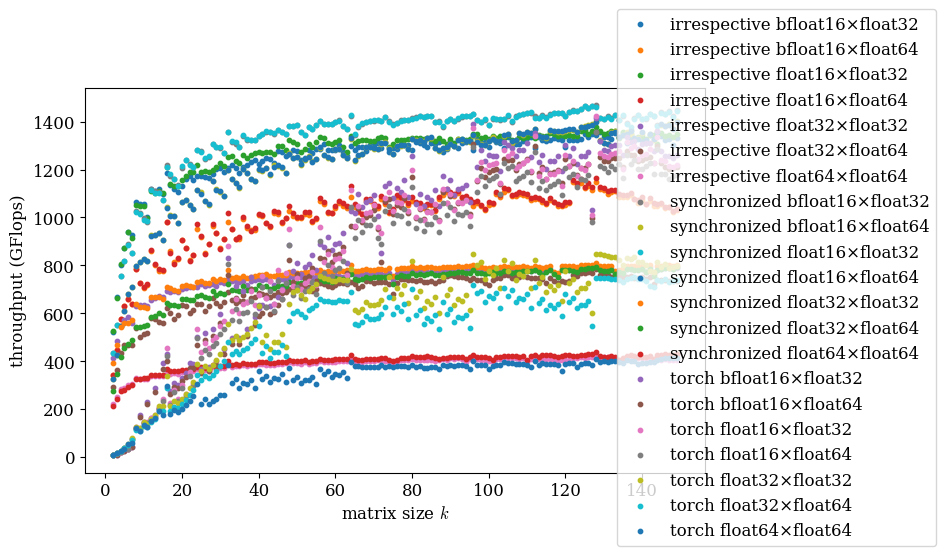

In [24]:
max_tput = df.pivot_table(
    values="GFlops",
    columns=["algorithm", "A_dtype", "b_dtype"],
    index="k",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("matrix size $k$")
ax.set_ylabel("throughput (GFlops)")

for col in max_tput.columns:
    ax.scatter(
        max_tput.index,
        max_tput[col],
        label=col[0] + " " + col[1] + "×" + col[2],
        s=10,
    )

fig.legend(loc="right", bbox_to_anchor=(1.2, 0.5))

In [25]:
df[df.k > 40].pivot_table(
    values="throughput",
    index=["A_dtype", "b_dtype"],
    columns="algorithm",
    aggfunc="max",
) / MEASURED_BANDWIDTH

algorithm         irrespective  synchronized     torch
A_dtype  b_dtype                                      
bfloat16 float32      0.788764      0.854719  0.824197
         float64      0.690997      0.841966  0.812083
float16  float32      0.808139      0.855070  0.827018
         float64      0.716962      0.843730  0.813779
float32  float32      0.915324      0.930855  0.976020
         float64      0.912784      0.921464  0.869753
float64  float64      0.971298      1.002993  0.943685

In [26]:
small_pivot = df[(df.k >= 21) & (df.k <= 60) & (df.A_dtype == "float16")].pivot_table(
    values="throughput",
    index=["A_dtype", "b_dtype", "k"],
    columns="algorithm",
    aggfunc="max",
)
small_pivot["irrespective / torch"] = small_pivot["irrespective"] / small_pivot["torch"]
small_pivot["synchronized / torch"] = small_pivot["synchronized"] / small_pivot["torch"]
small_pivot["synchronized / torch"].describe()

count    80.000000
mean      2.098381
std       0.611100
min       1.434176
25%       1.752996
50%       1.932544
75%       2.185792
max       4.753170
Name: synchronized / torch, dtype: float64